Saved → grid_10x4.pdf / grid_10x4.png


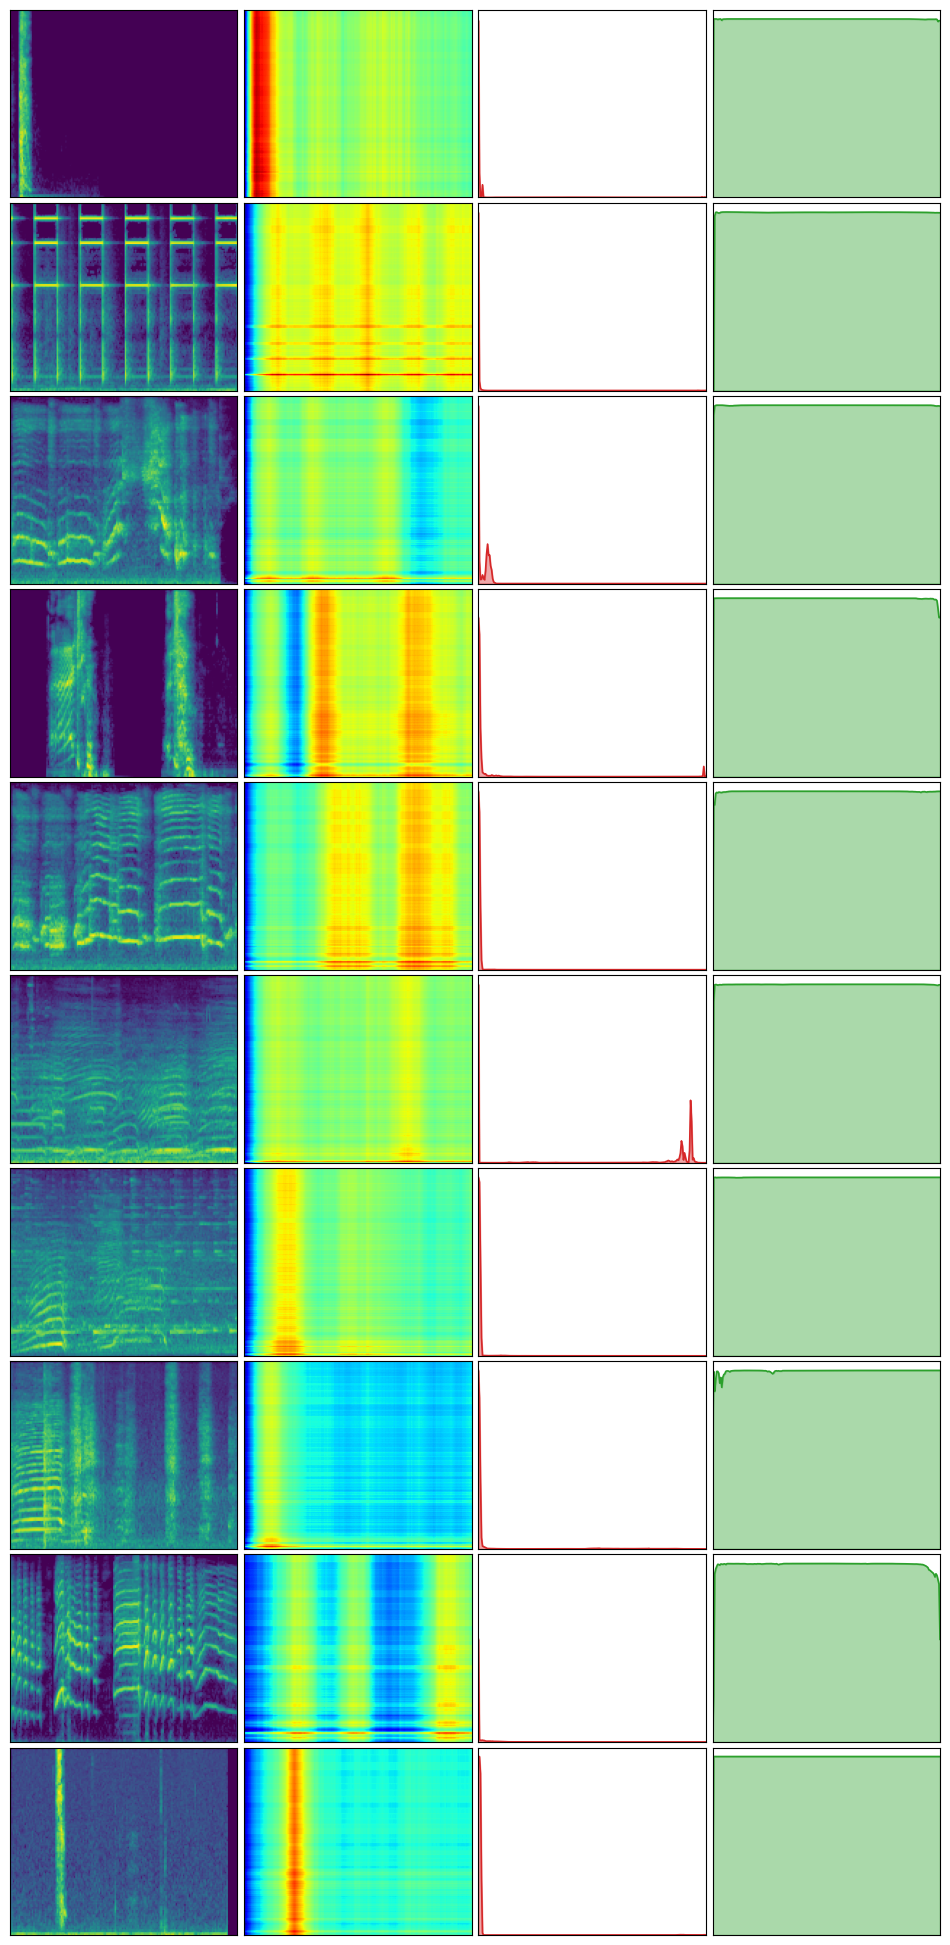

In [11]:
"""
Plots a 10-row × 4-column figure:
  Col 1: Log-Mel Spectrogram
  Col 2: Saliency Map
  Col 3: Deletion Curve
  Col 4: Insertion Curve

Rows correspond to the last 10 entries (indices 1–10) of the
deletion_curves.npy / insertion_curves.npy arrays.

Edit the paths in the CONFIG section before running.
"""

import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
from PIL import Image

# ── CONFIG ─────────────────────────────────────────────────────────────────────
AUDIO_DIR      = "test_audio"          # folder containing .wav files
SALIENCY_DIR   = "results/saliency/wav2vec2/results_report"
DELETION_PATH  = "results/saliency/wav2vec2/results_report/evaluation/deletion_curves.npy"
INSERTION_PATH = "results/saliency/wav2vec2/results_report/evaluation/insertion_curves.npy"

# The 10 filenames (rows 1–10), in order — edit if your order differs
FILENAMES = [
    "4-185415-A-21.wav",
    "5-210612-A-37.wav",
    "5-198411-B-20.wav",
    "4-157297-A-21.wav",
    "5-198411-E-20.wav",
    "4-181955-C-3.wav",
    "3-124376-A-3.wav",
    "1-69641-A-3.wav",
    "4-132816-A-26.wav",
    "3-142605-A-21.wav",
]

# Mel spectrogram params (must match your training pipeline)
SR         = 16000
N_FFT      = 1024
HOP_LENGTH = 512
N_MELS     = 128
# ──────────────────────────────────────────────────────────────────────────────


def load_logmel(wav_path):
    """Returns S_db (raw, for display) and S_224 (resized uint8)."""
    y, sr = librosa.load(wav_path, sr=SR)
    S = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
    )
    S_db = librosa.power_to_db(S, ref=np.max)
    S_norm = (S_db - S_db.min()) / (S_db.max() - S_db.min() + 1e-6)
    S_img  = (S_norm * 255).astype(np.uint8)
    pil_resized = Image.fromarray(S_img).convert("L").resize((224, 224), Image.BILINEAR)
    S_224 = np.array(pil_resized)
    return S_db, S_224


def load_saliency(wav_name):
    """Loads and normalises the saliency map for a given wav filename."""
    base = os.path.splitext(wav_name)[0]
    path = os.path.join(SALIENCY_DIR, base + ".wav_saliency.npy")
    sal  = np.load(path)
    sal  = (sal - sal.min()) / (sal.max() - sal.min() + 1e-8)
    return sal


# ── Load curves (rows 1–10) ────────────────────────────────────────────────────
deletion_all  = np.load(DELETION_PATH)   # (11, 225)
insertion_all = np.load(INSERTION_PATH)  # (11, 225)
deletion_curves  = deletion_all[1:]      # (10, 225)
insertion_curves = insertion_all[1:]     # (10, 225)
x = np.linspace(0, 1, deletion_curves.shape[1])

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(10, 4, figsize=(12, 25))
plt.subplots_adjust(wspace=0.03, hspace=0.03)

for row, fname in enumerate(FILENAMES):
    wav_path = os.path.join(AUDIO_DIR, fname)

    # --- load data ---
    S_db, S_224 = load_logmel(wav_path)
    saliency    = load_saliency(fname)
    del_curve   = deletion_curves[row]
    ins_curve   = insertion_curves[row]

    # --- Col 0: Log-Mel ---
    ax = axes[row, 0]
    ax.imshow(S_db, aspect='auto', origin='lower', cmap='viridis')
    ax.set_xticks([]); ax.set_yticks([])

    # --- Col 1: Saliency ---
    ax = axes[row, 1]
    ax.imshow(saliency, aspect='auto', origin='lower', cmap='jet')
    ax.set_xticks([]); ax.set_yticks([])

    # --- Col 2: Deletion curve ---
    ax = axes[row, 2]
    ax.plot(x, del_curve, color='tab:red', linewidth=1.2)
    ax.fill_between(x, del_curve, color='tab:red', alpha=0.4)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
    ax.set_xticks([]); ax.set_yticks([])

    # --- Col 3: Insertion curve ---
    ax = axes[row, 3]
    ax.plot(x, ins_curve, color='tab:green', linewidth=1.2)
    ax.fill_between(x, ins_curve, color='tab:green', alpha=0.4)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
    ax.set_xticks([]); ax.set_yticks([])

plt.savefig("grid_10x4.pdf", dpi=300, bbox_inches='tight')
plt.savefig("grid_10x4.png", dpi=300, bbox_inches='tight')
print("Saved → grid_10x4.pdf / grid_10x4.png")
plt.show()

In [9]:
%ls results/saliency/wav2vec2/results_report/

1-69641-A-3.wav_saliency.npy    4-181955-C-3.wav_saliency.npy
3-124376-A-3.wav_saliency.npy   4-185415-A-21.wav_saliency.npy
3-142605-A-21.wav_saliency.npy  5-198411-B-20.wav_saliency.npy
4-132816-A-26.wav_saliency.npy  5-198411-E-20.wav_saliency.npy
4-157297-A-21.wav_saliency.npy  5-210612-A-37.wav_saliency.npy
4-161303-A-5.wav_saliency.npy   evaluation/


Saved → waveform_based_insertion_deletion_curve_RISE.pdf


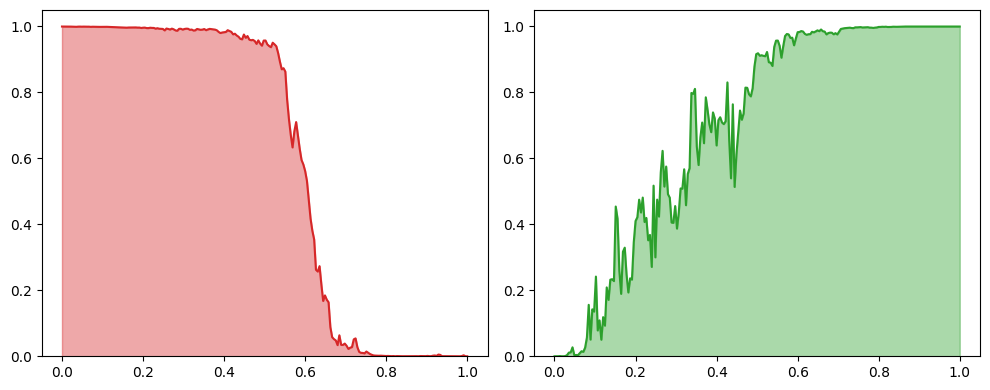

In [8]:
import numpy as np
import matplotlib.pyplot as plt

deletion_curves = np.load('waveform_based_results/deletion_curves_wav2vec2_RISE.npy')[0]
insertion_curves = np.load('waveform_based_results/insertion_curves_wav2vec2_RISE.npy')[0]

x = np.linspace(0, 1, len(deletion_curves))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(x, deletion_curves, color='tab:red')
ax1.fill_between(x, deletion_curves, color='tab:red', alpha=0.4)
ax1.set_ylim(0, 1.05)

ax2.plot(x, insertion_curves, color='tab:green')
ax2.fill_between(x, insertion_curves, color='tab:green', alpha=0.4)
ax2.set_ylim(0, 1.05)

plt.savefig("waveform_based_results/waveform_based_insertion_deletion_curve_RISE.pdf", dpi=300, bbox_inches='tight')
print("Saved → waveform_based_insertion_deletion_curve_RISE.pdf")
plt.tight_layout()
plt.show()

Saved → waveform_based_insertion_deletion_curve_RISE_WAVE.pdf


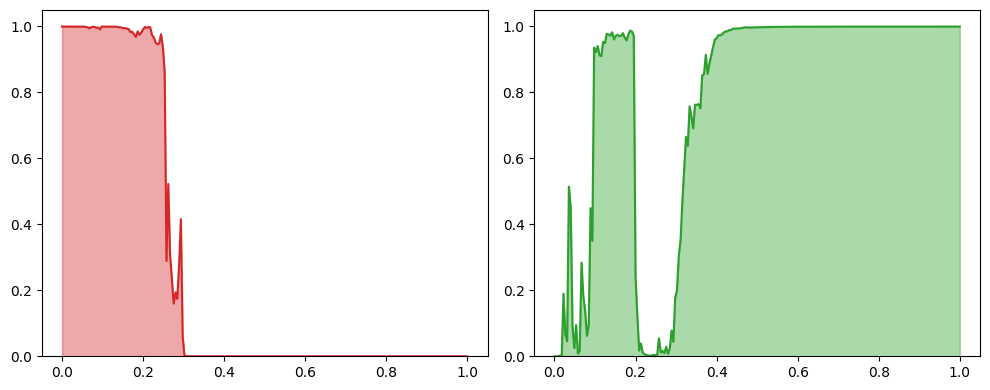

In [9]:
import numpy as np
import matplotlib.pyplot as plt

deletion_curves = np.load('waveform_based_results/deletion_curves_wav2vec2_RISE_WAVE.npy')[0]
insertion_curves = np.load('waveform_based_results/insertion_curves_wav2vec2_RISE_WAVE.npy')[0]

x = np.linspace(0, 1, len(deletion_curves))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(x, deletion_curves, color='tab:red')
ax1.fill_between(x, deletion_curves, color='tab:red', alpha=0.4)
ax1.set_ylim(0, 1.05)

ax2.plot(x, insertion_curves, color='tab:green')
ax2.fill_between(x, insertion_curves, color='tab:green', alpha=0.4)
ax2.set_ylim(0, 1.05)

plt.savefig("waveform_based_results/waveform_based_insertion_deletion_curve_RISE_WAVE.pdf", dpi=300, bbox_inches='tight')
print("Saved → waveform_based_insertion_deletion_curve_RISE_WAVE.pdf")
plt.tight_layout()
plt.show()

Saved → waveform_based_insertion_deletion_curve_LIME.pdf


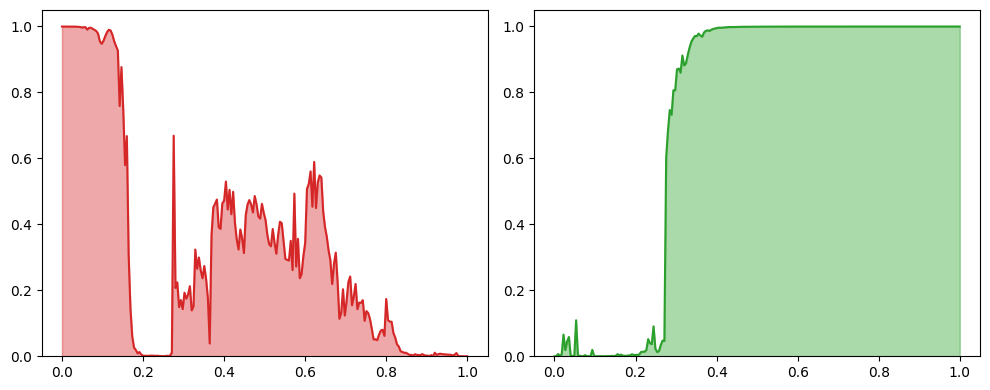

In [10]:
import numpy as np
import matplotlib.pyplot as plt

deletion_curves = np.load('waveform_based_results/deletion_curves_wav2vec2_LIME.npy')[0]
insertion_curves = np.load('waveform_based_results/insertion_curves_wav2vec2_LIME.npy')[0]

x = np.linspace(0, 1, len(deletion_curves))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(x, deletion_curves, color='tab:red')
ax1.fill_between(x, deletion_curves, color='tab:red', alpha=0.4)
ax1.set_ylim(0, 1.05)

ax2.plot(x, insertion_curves, color='tab:green')
ax2.fill_between(x, insertion_curves, color='tab:green', alpha=0.4)
ax2.set_ylim(0, 1.05)

plt.savefig("waveform_based_results/waveform_based_insertion_deletion_curve_LIME.pdf", dpi=300, bbox_inches='tight')
print("Saved → waveform_based_insertion_deletion_curve_LIME.pdf")
plt.tight_layout()
plt.show()

Saved → waveform_based_insertion_deletion_curve_RISE_Audio.pdf


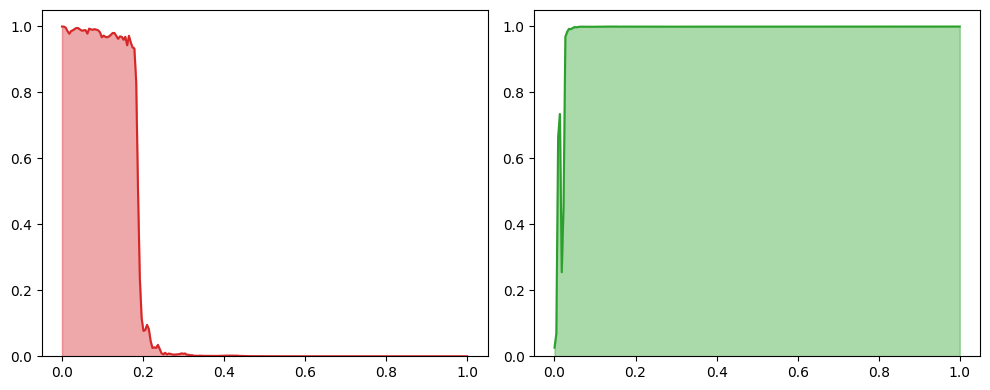

In [12]:
import numpy as np
import matplotlib.pyplot as plt

deletion_curves = np.load('waveform_based_results/deletion_curves_wav2vec2_rise_audio.npy')[0]
insertion_curves = np.load('waveform_based_results/insertion_curves_wav2vec2_rise_audio.npy')[0]

x = np.linspace(0, 1, len(deletion_curves))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(x, deletion_curves, color='tab:red')
ax1.fill_between(x, deletion_curves, color='tab:red', alpha=0.4)
ax1.set_ylim(0, 1.05)

ax2.plot(x, insertion_curves, color='tab:green')
ax2.fill_between(x, insertion_curves, color='tab:green', alpha=0.4)
ax2.set_ylim(0, 1.05)

plt.savefig("waveform_based_results/insertion_deletion_curve_RISE_Audio.pdf", dpi=300, bbox_inches='tight')
print("Saved → waveform_based_insertion_deletion_curve_RISE_Audio.pdf")
plt.tight_layout()
plt.show()